# Task 4. Model Development and Training

In [146]:
#import the warnings.
import warnings
warnings.filterwarnings("ignore")

In [148]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [150]:
df = pd.read_csv("clean-dataset/unified_dataset.csv")

In [152]:
df.head()

,date,Hour,Junction,Vehicles,DayOfWeek,Month,Weekend,Vehicles_Lag1,Vehicles_Lag24,temperature,dew_point,specific humidity,relative_humidity,precipitation,wind_speed,holiday
0,2015-01-11,0,1,0.078212,6,1,1,0.078212,0.078212,0.091972,0.285254,0.084939,0.428017,0.0,0.353586,0
1,2015-01-11,0,2,0.027933,6,1,1,0.078212,0.078212,0.091972,0.285254,0.084939,0.428017,0.0,0.353586,0
2,2015-01-11,0,3,0.044693,6,1,1,0.078212,0.078212,0.091972,0.285254,0.084939,0.428017,0.0,0.353586,0
3,2015-01-11,1,1,0.067039,6,1,1,0.078212,0.078212,0.075332,0.280423,0.083187,0.445843,0.0,0.349602,0
4,2015-01-11,1,2,0.027933,6,1,1,0.027933,0.078212,0.075332,0.280423,0.083187,0.445843,0.0,0.349602,0


# 1. ARIMA model

## i. Model Building 

In [155]:
df.dtypes

date                  object
Hour                   int64
Junction               int64
Vehicles             float64
DayOfWeek              int64
Month                  int64
Weekend                int64
Vehicles_Lag1        float64
Vehicles_Lag24       float64
temperature          float64
dew_point            float64
specific humidity    float64
relative_humidity    float64
precipitation        float64
wind_speed           float64
holiday                int64
dtype: object

In [157]:
# Create a copy of the original DataFrame for ARIMA modeling
df_arima = df.copy()

In [159]:
df_arima.head()

,date,Hour,Junction,Vehicles,DayOfWeek,Month,Weekend,Vehicles_Lag1,Vehicles_Lag24,temperature,dew_point,specific humidity,relative_humidity,precipitation,wind_speed,holiday
0,2015-01-11,0,1,0.078212,6,1,1,0.078212,0.078212,0.091972,0.285254,0.084939,0.428017,0.0,0.353586,0
1,2015-01-11,0,2,0.027933,6,1,1,0.078212,0.078212,0.091972,0.285254,0.084939,0.428017,0.0,0.353586,0
2,2015-01-11,0,3,0.044693,6,1,1,0.078212,0.078212,0.091972,0.285254,0.084939,0.428017,0.0,0.353586,0
3,2015-01-11,1,1,0.067039,6,1,1,0.078212,0.078212,0.075332,0.280423,0.083187,0.445843,0.0,0.349602,0
4,2015-01-11,1,2,0.027933,6,1,1,0.027933,0.078212,0.075332,0.280423,0.083187,0.445843,0.0,0.349602,0


In [161]:
# Step 1: Convert 'date' to datetime format (for ARIMA model)
df_arima['date'] = pd.to_datetime(df_arima['date'])

# Step 2: Combine 'date' and 'hour' into a datetime column
df_arima['datetime'] = pd.to_datetime(df_arima['date'].astype(str) + ' ' + df_arima['Hour'].astype(str) + ':00:00')

In [163]:
df_arima.dtypes

date                 datetime64[ns]
Hour                          int64
Junction                      int64
Vehicles                    float64
DayOfWeek                     int64
Month                         int64
Weekend                       int64
Vehicles_Lag1               float64
Vehicles_Lag24              float64
temperature                 float64
dew_point                   float64
specific humidity           float64
relative_humidity           float64
precipitation               float64
wind_speed                  float64
holiday                       int64
datetime             datetime64[ns]
dtype: object

In [165]:
# Step 3: Set 'datetime' as the index
df_arima.set_index('datetime', inplace=True)

# Step 4: Keep only the 'Vehicles' column (the target variable for ARIMA)
df_arima = df_arima[['Vehicles']]

In [167]:
df_arima.head()

,Vehicles
datetime,
2015-01-11 00:00:00,0.078212
2015-01-11 00:00:00,0.027933
2015-01-11 00:00:00,0.044693
2015-01-11 01:00:00,0.067039
2015-01-11 01:00:00,0.027933


In [169]:
# checking missing values
df_arima.isnull().mean() * 100

Vehicles    0.0
dtype: float64

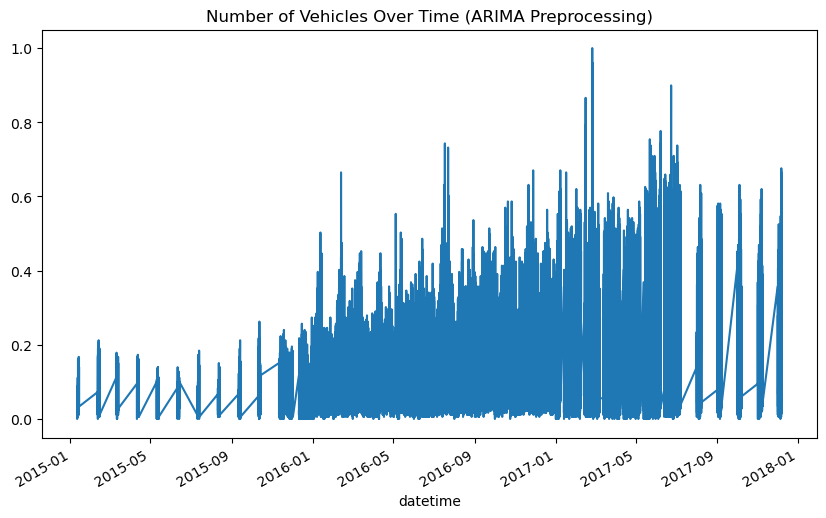

In [171]:
# Visualize the data
import matplotlib.pyplot as plt
df_arima['Vehicles'].plot(figsize=(10, 6))
plt.title('Number of Vehicles Over Time (ARIMA Preprocessing)')
plt.show()

In [172]:
# Perform the ADF test to check if the data is stationary
def adf_test(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("stationary")
    else:
        print("non-stationary")
        
# Test stationarity of the 'Vehicles' column
adf_test(df_arima['Vehicles'])

ADF Statistic: -16.99149041920314
p-value: 8.862306776606597e-30
stationary


<b>Since both the ADF statistic is significantly negative and the p-value is much less than 0.05, we can conclude that the time series data i.e., the Vehicles column is stationary.

In [175]:
# Step 1: Split the data into training and test sets (70:30 split)
train_size = int(len(df_arima) * 0.70)
train_arima, test_arima = df_arima[:train_size], df_arima[train_size:]

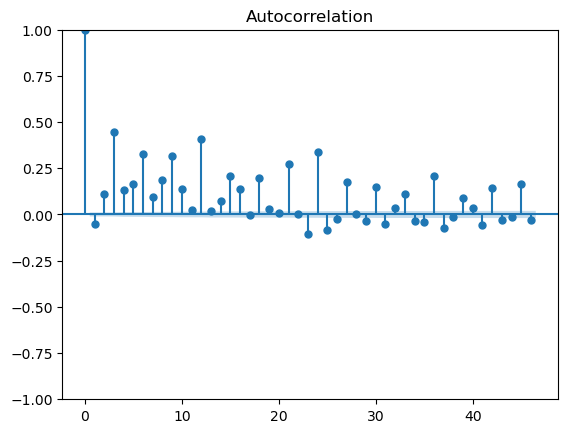

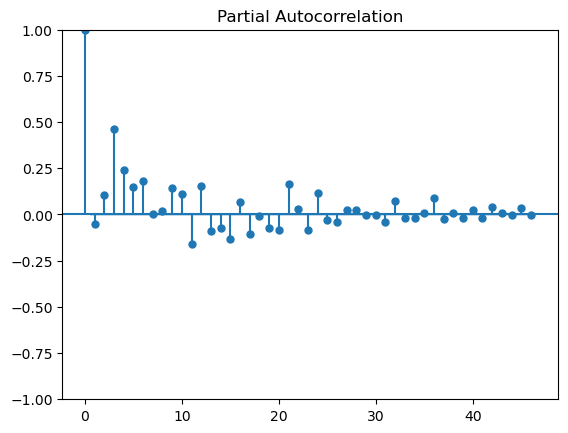

In [176]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF to help decide p and q
plot_acf(train_arima)
plot_pacf(train_arima)
plt.show()

In [231]:
# Fit the ARIMA model
model_arima = ARIMA(train_arima, order=(1, 0, 0)) 
model_arima_fit = model_arima.fit()

In [232]:
# View the model summary
print(model_arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               Vehicles   No. Observations:                33684
Model:                 ARIMA(1, 0, 0)   Log Likelihood               30847.856
Date:                Fri, 07 Feb 2025   AIC                         -61689.713
Time:                        16:00:24   BIC                         -61664.439
Sample:                             0   HQIC                        -61681.648
                              - 33684                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1085      0.001    133.954      0.000       0.107       0.110
ar.L1         -0.0534      0.007     -7.120      0.000      -0.068      -0.039
sigma2         0.0094   7.35e-05    127.595      0.0

In [234]:
# Generate predictions for the test dataset
# The number of steps should match the length of the test dataset
n_steps_test = len(test_arima)
predictions_arima_test = model_arima_fit.forecast(steps=n_steps_test)

# Create a DataFrame for the predicted values
predictions_arima_test_df = pd.DataFrame(predictions_arima_test, index=test_arima.index, columns=['Predicted'])

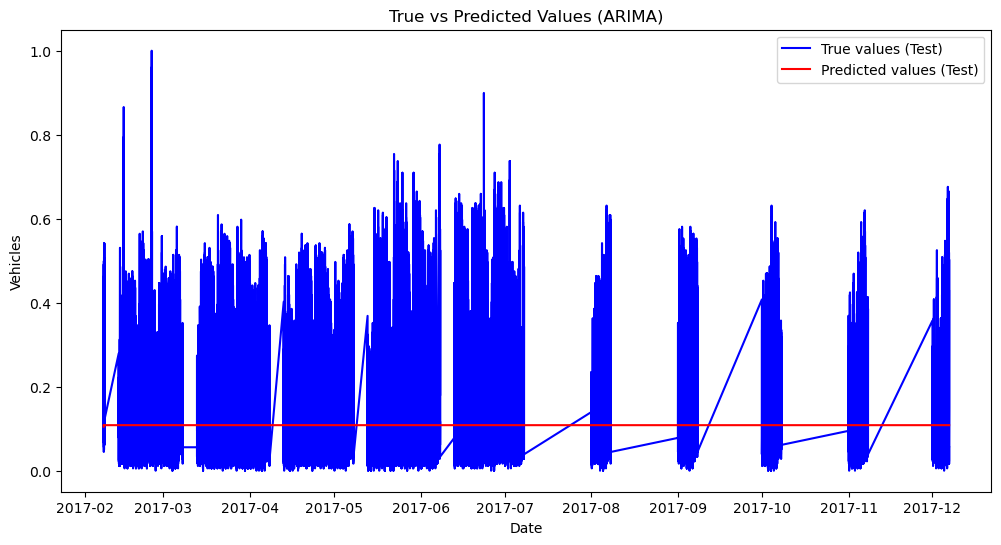

In [237]:
# Plot the results
plt.figure(figsize=(12, 6))

# Plot true values for test data
plt.plot(test_arima.index, test_arima, label='True values (Test)', color='blue')

# Plot predictions for test data
plt.plot(test_arima.index, predictions_arima_test, label='Predicted values (Test)', color='red')

# Add labels and title
plt.xlabel('Date')
plt.ylabel('Vehicles')
plt.title('True vs Predicted Values (ARIMA)')
plt.legend()

# Show the plot
plt.show()

## ii. Evaluate model performance

In [280]:
mae = mean_absolute_error(test_arima, predictions_arima_test)
rmse = np.sqrt(mean_squared_error(test_arima, predictions_arima_test))
r2 = r2_score(test_arima, predictions_arima_test)

print(f'Mean Absolute Error (MAE): {mae}')
print(f'Root Mean Square Error (RMSE): {rmse}')
print(f'R-squared: {r2}')

Mean Absolute Error (MAE): 0.10326566194604825
Root Mean Square Error (RMSE): 0.15309095534659473
R-squared: -0.09108632425292007


## iii. Residuals

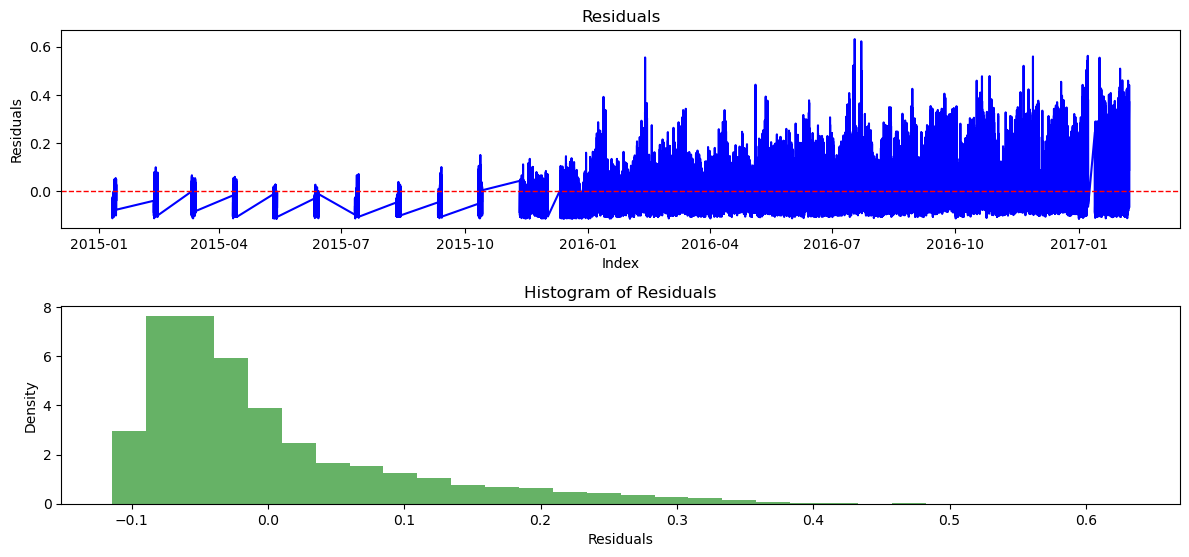

In [247]:
# Get residuals
residuals = model_arima_fit.resid

# Residual Visualization
plt.figure(figsize=(12, 8))

# Plot residuals
plt.subplot(3, 1, 1)
plt.plot(residuals, color='blue')
plt.title('Residuals')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Plot histogram of residuals
plt.subplot(3, 1, 2)
plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

# 2. LSTM Model

## i. Model Building

In [48]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [49]:
df_lstm = df.copy()

In [50]:
# Step 1: Split the data into training and test sets (70:30 split)
train_size = int(len(df_lstm) * 0.70)
train_lstm, test_lstm = df_lstm[:train_size], df_lstm[train_size:]

In [54]:
# Create dataset for time series prediction (X, y)
def create_dataset(df_lstm, time_step=1):
    X, y = [], []
    for i in range(len(df_lstm) - time_step - 1):
        X.append(df_lstm[i:(i + time_step), 0])  # X takes the last 'time_step' values
        y.append(df_lstm[i + time_step, 0])  # y is the next value to predict
    return np.array(X), np.array(y)

time_step = 24  # Look at the past 24 hours (this can be adjusted)

In [56]:
X_train, y_train = create_dataset(train_lstm[['Vehicles']].values, time_step)
X_test, y_test = create_dataset(test_lstm[['Vehicles']].values, time_step)

# Reshape input data to be in the form [samples, time_steps, features] for LSTM
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [58]:
# Build the LSTM model
model_lstm = Sequential()
model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
model_lstm.add(LSTM(units=50, return_sequences=False))
model_lstm.add(Dense(units=1))

In [60]:
# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model_lstm.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 32s 24ms/step - loss: 0.0080
Epoch 2/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - loss: 0.0064
Epoch 3/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - loss: 0.0061
Epoch 4/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - loss: 0.0060
Epoch 5/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - loss: 0.0055
Epoch 6/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 41s 23ms/step - loss: 0.0052
Epoch 7/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0048
Epoch 8/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - loss: 0.0044
Epoch 9/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - loss: 0.0039
Epoch 10/10
1052/1052 ━━━━━━━━━━━━━━━━━━━━ 24s 23ms/step - loss: 0.0037


In [82]:
# Predict with the model
y_pred = model_lstm.predict(X_test)

451/451 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


In [84]:
# Since predicted_lstm will be in the form of a 2D array, you may need to flatten it
y_pred = y_pred.flatten()

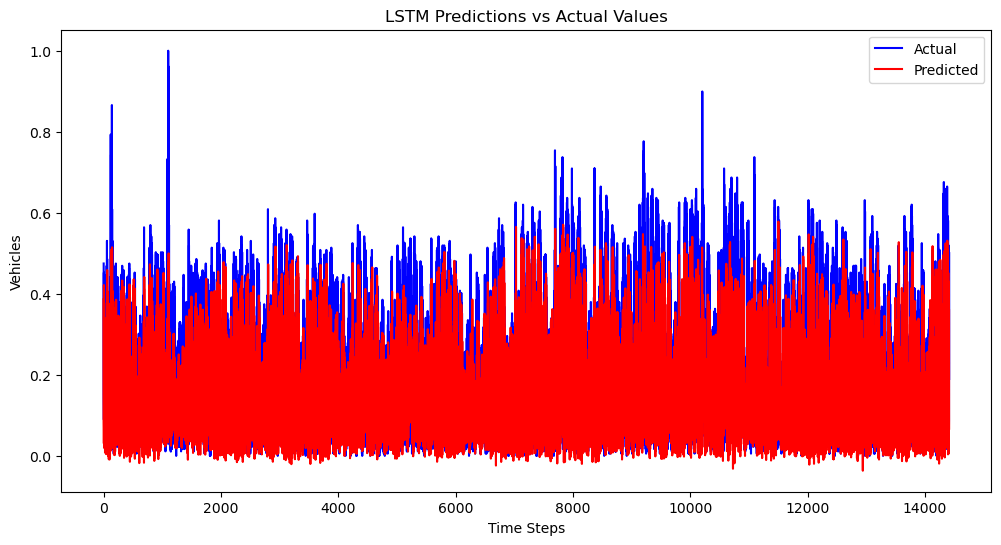

In [86]:
# Assuming y_test is the actual values for the test set
y_test = y_test.flatten() 

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='blue')
plt.plot(y_pred, label='Predicted', color='red')
plt.title('LSTM Predictions vs Actual Values')
plt.xlabel('Time Steps')
plt.ylabel('Vehicles')
plt.legend()
plt.show()

## ii. Evaluate model performance

In [88]:
# Evaluate model performance
mae_lstm = mean_absolute_error(y_test, y_pred)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred))
r2_lstm = r2_score(y_test, y_pred)

print(f'LSTM - MAE: {mae_lstm}, RMSE: {rmse_lstm}, R-squared: {r2_lstm}')

LSTM - MAE: 0.07602981169401601, RMSE: 0.11067495580280878, R-squared: 0.42921095193532544


# Residuals

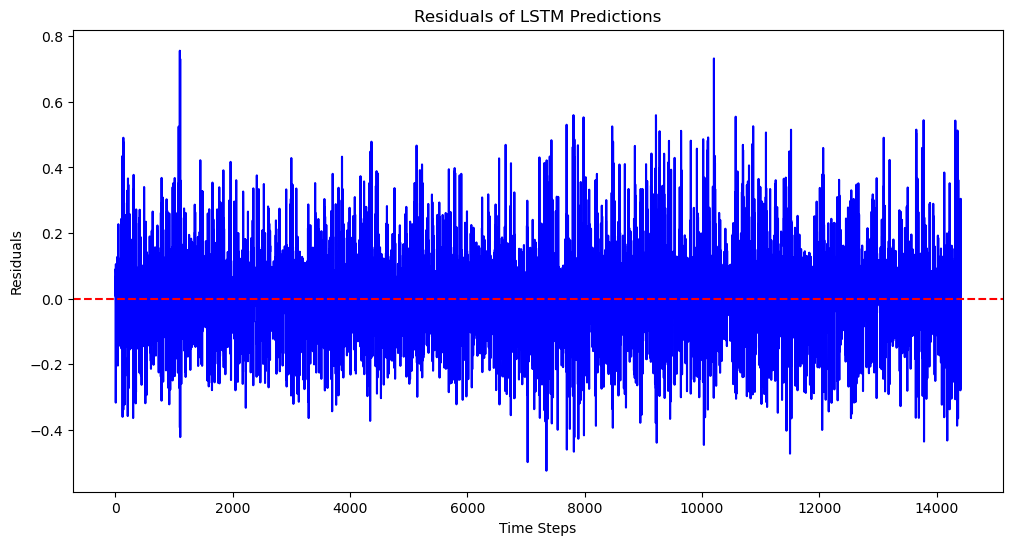

In [92]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(12, 6))
plt.plot(residuals, color='blue')
plt.title('Residuals of LSTM Predictions')
plt.xlabel('Time Steps')
plt.ylabel('Residuals')
plt.axhline(0, color='red', linestyle='--')  # Add a horizontal line at 0
plt.show()

# 3. Gradient Boosting Trees

## i. Model building

In [251]:
df_gb = df.copy()

In [253]:
df_gb.columns

Index(['date', 'Hour', 'Junction', 'Vehicles', 'DayOfWeek', 'Month', 'Weekend',
       'Vehicles_Lag1', 'Vehicles_Lag24', 'temperature', 'dew_point',
       'specific humidity', 'relative_humidity', 'precipitation', 'wind_speed',
       'holiday'],
      dtype='object')

In [255]:
from sklearn.ensemble import GradientBoostingRegressor

# Step 1: Split the data into training and test sets (70:30 split)
train_size = int(len(df_gb) * 0.70)
train, test = df_gb[:train_size], df_gb[train_size:]

# Prepare the feature matrix X and target vector y
X_train_gb = train[['Vehicles_Lag1', 'Vehicles_Lag24', 'temperature', 'dew_point', 'specific humidity', 
                         'relative_humidity', 'precipitation', 'wind_speed', 'holiday', 'Hour', 'DayOfWeek']]
y_train_gb = train['Vehicles']

X_test_gb = test[['Vehicles_Lag1', 'Vehicles_Lag24', 'temperature', 'dew_point', 'specific humidity', 
                       'relative_humidity', 'precipitation', 'wind_speed', 'holiday', 'Hour', 'DayOfWeek']]
y_test_gb = test['Vehicles']

In [257]:
# Fit the model
model_gb = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3)
model_gb.fit(X_train_gb, y_train_gb)

GradientBoostingRegressor()

In [258]:
# Predict
predicted_gb_train = model_gb.predict(X_train_gb)
predicted_gb_test = model_gb.predict(X_test_gb)

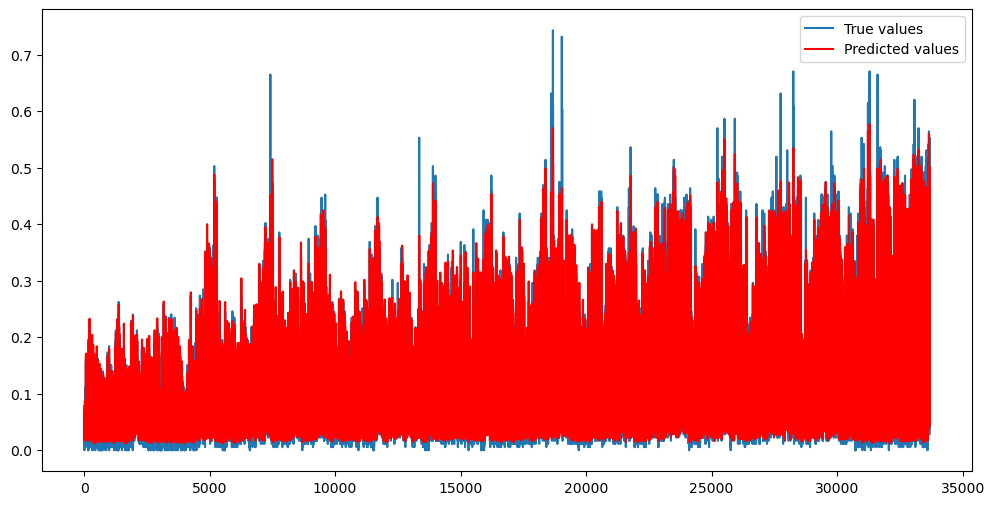

In [259]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(train.index, y_train_gb, label='True values')
plt.plot(train.index, predicted_gb_train, label='Predicted values', color='red')
plt.legend()
plt.show()

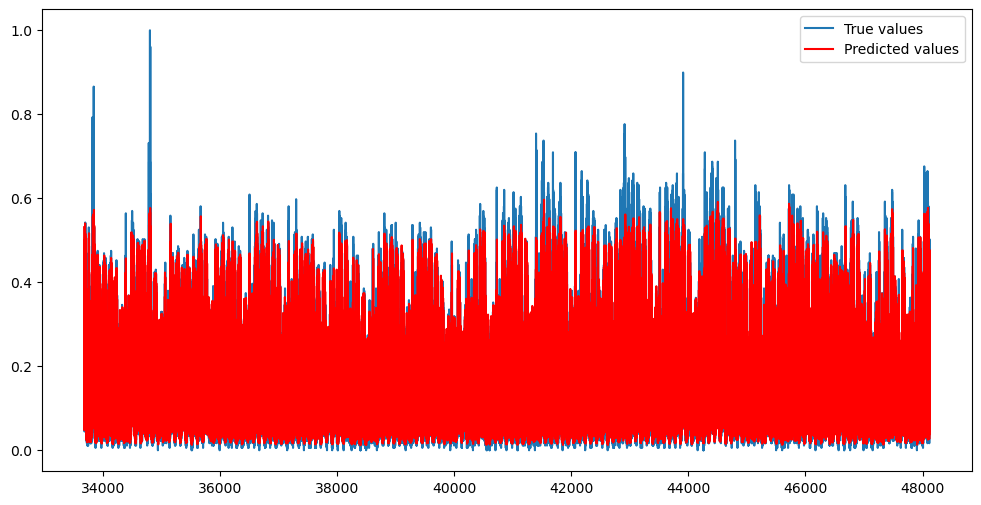

In [260]:
# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test_gb, label='True values')
plt.plot(test.index, predicted_gb_test, label='Predicted values', color='red')
plt.legend()
plt.show()

## ii. Evaluate model performance

In [267]:
# Evaluate model performance
mae_gb = mean_absolute_error(y_test_gb, predicted_gb_test)
rmse_gb = np.sqrt(mean_squared_error(y_test_gb, predicted_gb_test))
r2_gb = r2_score(y_test_gb, predicted_gb_test)

print(f'Gradient Boosting - MAE: {mae_gb}, RMSE: {rmse_gb}, R-squared: {r2_gb}')

Gradient Boosting - MAE: 0.018195356821334083, RMSE: 0.030153241861316554, R-squared: 0.9576719688294908


## iii. Residuals

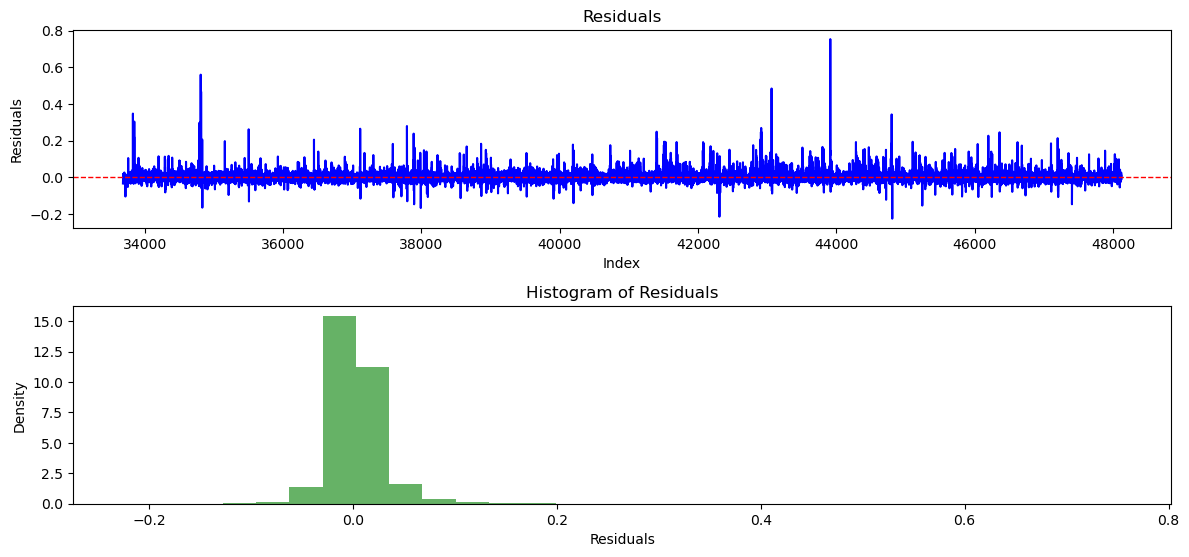

In [301]:
# Calculate residuals
residuals = y_test_gb - predicted_gb_test

# Residual Visualization
plt.figure(figsize=(12, 8))

# Plot residuals
plt.subplot(3, 1, 1)
plt.plot(residuals, color='blue')
plt.title('Residuals')
plt.xlabel('Index')
plt.ylabel('Residuals')
plt.axhline(0, color='red', linestyle='--', linewidth=1)

# Plot histogram of residuals
plt.subplot(3, 1, 2)
plt.hist(residuals, bins=30, density=True, alpha=0.6, color='g')
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Density')

plt.tight_layout()
plt.show()